# TVM OSDI '18 Reproduction

In [1]:
#@title Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#@title Configure project and result paths
from pathlib import Path
import os

REPO_URL = "https://github.com/baoyunfan0101/tvm-osdi18-reproduction"
PROJECT_DIR = Path("/content/tvm-osdi18-reproduction")
RESULTS_ROOT = Path("/content/drive/MyDrive/tvm-osdi18-reproduction")

EXP1_RESULTS_DIR = RESULTS_ROOT / "exp1_graph_level" / "results"
EXP2_RESULTS_DIR = RESULTS_ROOT / "exp2_operator_level" / "results"
EXP3_RESULTS_DIR = RESULTS_ROOT / "exp3_end2end" / "results"

for path in [RESULTS_ROOT, EXP1_RESULTS_DIR, EXP2_RESULTS_DIR, EXP3_RESULTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Results root:", RESULTS_ROOT)

Project directory: /content/tvm-osdi18-reproduction
Results root: /content/drive/MyDrive/tvm-osdi18-reproduction


In [3]:
#@title Clone project from GitHub
import shutil
import os
from pathlib import Path

if PROJECT_DIR.exists():
    shutil.rmtree(PROJECT_DIR)

!git clone {REPO_URL} {PROJECT_DIR}

os.chdir(PROJECT_DIR)
print("Current working directory:", Path.cwd())

Cloning into '/content/tvm-osdi18-reproduction'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 43 (delta 12), reused 41 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 20.10 KiB | 2.51 MiB/s, done.
Resolving deltas: 100% (12/12), done.
Current working directory: /content/tvm-osdi18-reproduction


In [4]:
#@title Setup
!bash env/colab_setup.sh

[Colab Setup 1/9] Checking Python version...
Python version: 3.11.13
[Colab Setup 2/9] Checking GPU...
Thu Apr  9 09:51:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                    

In [5]:
#@title Install dependencies
!pip install -r requirements.txt

In [6]:
#@title Import
from IPython.display import Image, display

## Experiment 1: Graph Level

In [7]:
#@title Run on CPU
!python -m exp1_graph_level.run_fusion --target llvm --platform colab_cpu --workload conv_bias_relu --output "{EXP1_RESULTS_DIR / 'colab_cpu_conv_bias_relu.json'}"
!python -m exp1_graph_level.run_fusion --target llvm --platform colab_cpu --workload conv_bn_relu --output "{EXP1_RESULTS_DIR / 'colab_cpu_conv_bn_relu.json'}"

One or more operators have not been tuned. Please tune your model for better performance. Use DEBUG logging level to see more details.
Exp1: Graph-Level Optimization
Platform: colab_cpu
Target: llvm
Workload: conv_bias_relu
No graph optimization mean latency: 5.301942 ms
Graph optimization mean latency:    4.755384 ms
Speedup: 1.1149x
Saved results to: /content/drive/MyDrive/tvm-osdi18-reproduction/exp1_graph_level/results/colab_cpu_conv_bias_relu.json
One or more operators have not been tuned. Please tune your model for better performance. Use DEBUG logging level to see more details.
Exp1: Graph-Level Optimization
Platform: colab_cpu
Target: llvm
Workload: conv_bn_relu
No graph optimization mean latency: 5.735703 ms
Graph optimization mean latency:    4.439869 ms
Speedup: 1.2919x
Saved results to: /content/drive/MyDrive/tvm-osdi18-reproduction/exp1_graph_level/results/colab_cpu_conv_bn_relu.json


In [8]:
#@title Run on GPU
!python -m exp1_graph_level.run_fusion --target cuda --platform colab_gpu --workload conv_bias_relu --output "{EXP1_RESULTS_DIR / 'colab_gpu_conv_bias_relu.json'}"
!python -m exp1_graph_level.run_fusion --target cuda --platform colab_gpu --workload conv_bn_relu --output "{EXP1_RESULTS_DIR / 'colab_gpu_conv_bn_relu.json'}"

One or more operators have not been tuned. Please tune your model for better performance. Use DEBUG logging level to see more details.
Exp1: Graph-Level Optimization
Platform: colab_gpu
Target: cuda
Workload: conv_bias_relu
No graph optimization mean latency: 0.058487 ms
Graph optimization mean latency:    0.003554 ms
Speedup: 16.4562x
Saved results to: /content/drive/MyDrive/tvm-osdi18-reproduction/exp1_graph_level/results/colab_gpu_conv_bias_relu.json
One or more operators have not been tuned. Please tune your model for better performance. Use DEBUG logging level to see more details.
Exp1: Graph-Level Optimization
Platform: colab_gpu
Target: cuda
Workload: conv_bn_relu
No graph optimization mean latency: 0.130431 ms
Graph optimization mean latency:    0.003599 ms
Speedup: 36.2381x
Saved results to: /content/drive/MyDrive/tvm-osdi18-reproduction/exp1_graph_level/results/colab_gpu_conv_bn_relu.json


In [9]:
#@title Plot
!python -m exp1_graph_level.plot --results-dir "{EXP1_RESULTS_DIR}" --output "{EXP1_RESULTS_DIR / 'fusion_comparison.png'}" --summary-output "{EXP1_RESULTS_DIR / 'summary.json'}"

Saved: /content/drive/MyDrive/tvm-osdi18-reproduction/exp1_graph_level/results/fusion_comparison.png


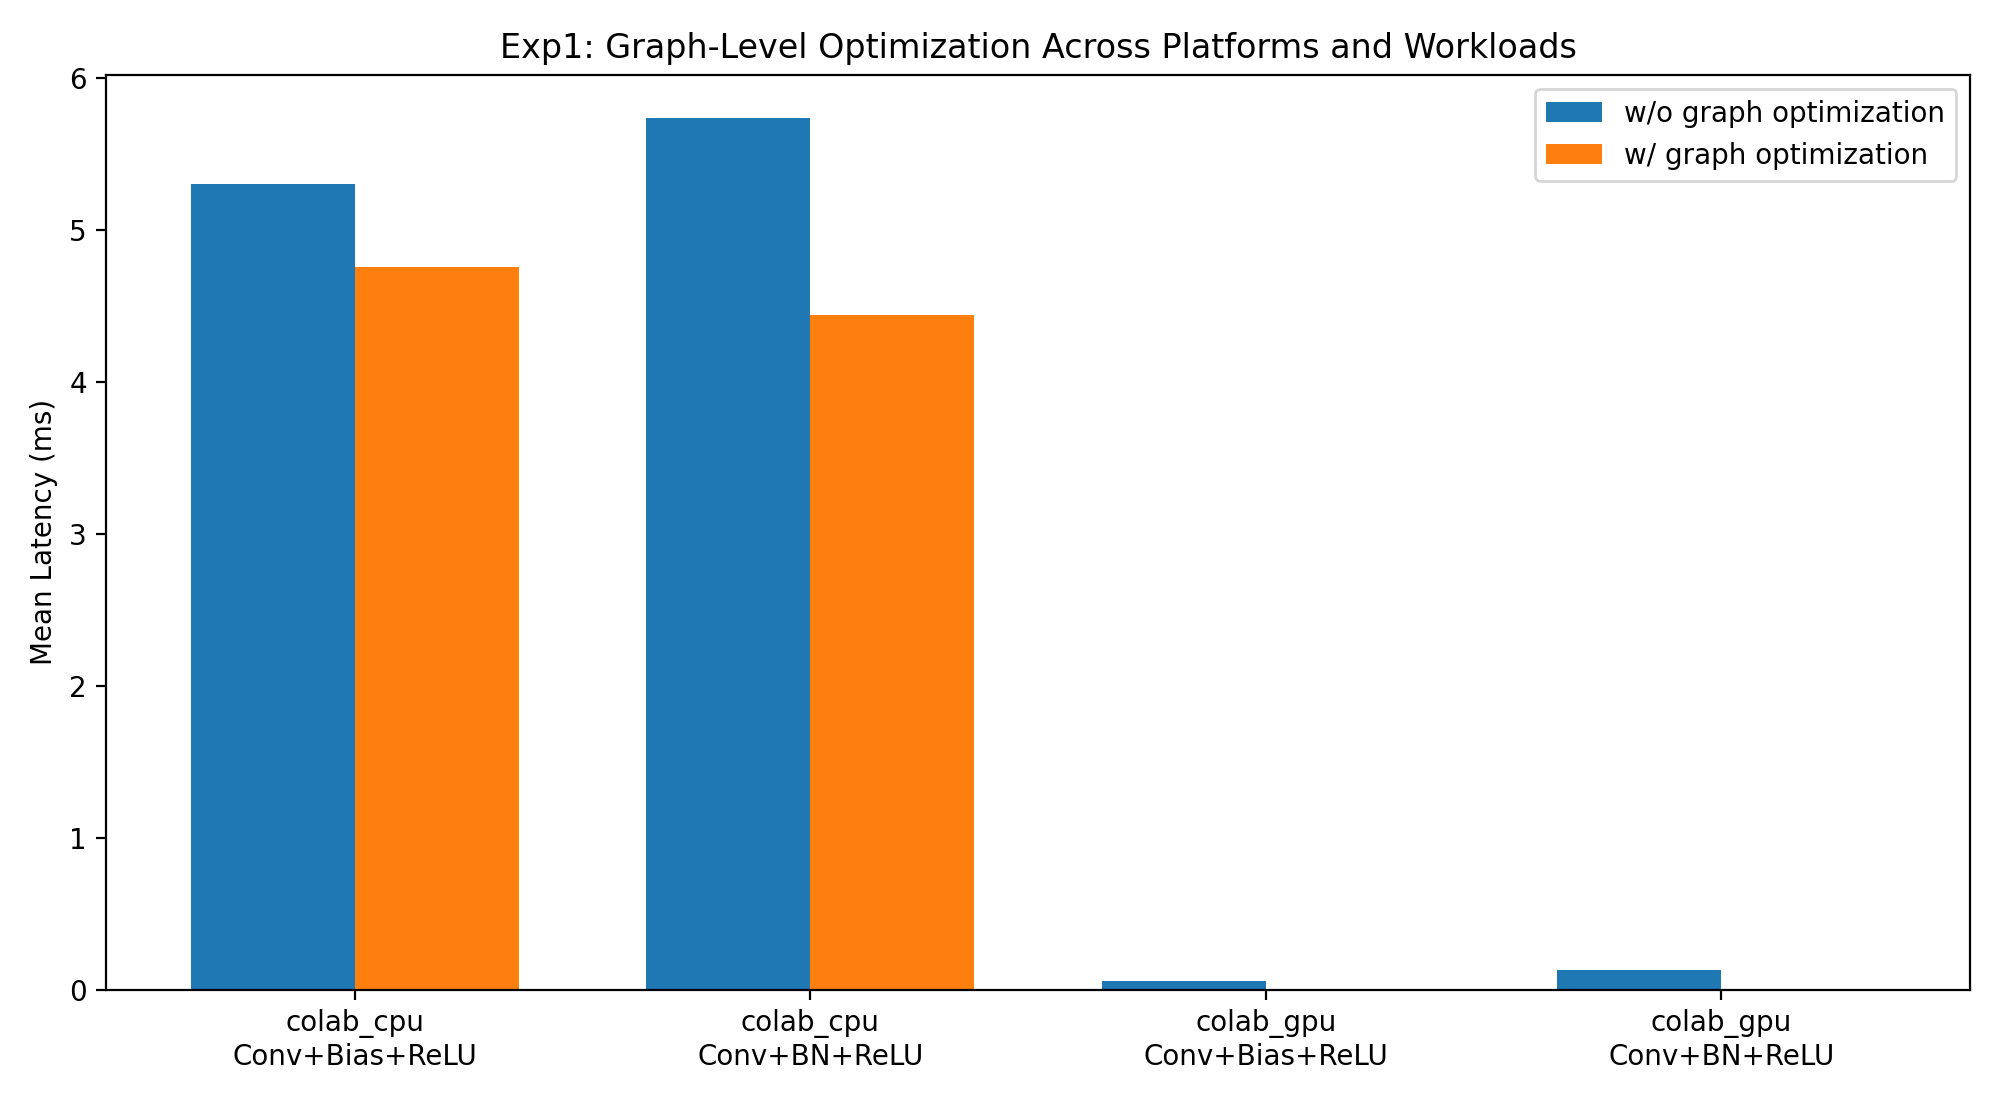

In [10]:
#@title Display
display(Image(str(EXP1_RESULTS_DIR / "fusion_comparison.png")))

## Experiment 2: Operator Level

In [11]:
#@title Run on CPU
!python -m exp2_operator_level.run_tuning --target llvm --platform colab_cpu --workload conv2d --trials 50 --results-dir "{EXP2_RESULTS_DIR}" --output "{EXP2_RESULTS_DIR / 'colab_cpu_conv2d.json'}" --log-output "{EXP2_RESULTS_DIR / 'colab_cpu_conv2d_log.json'}"
!python -m exp2_operator_level.run_tuning --target llvm --platform colab_cpu --workload depthwise --trials 50 --results-dir "{EXP2_RESULTS_DIR}" --output "{EXP2_RESULTS_DIR / 'colab_cpu_depthwise.json'}" --log-output "{EXP2_RESULTS_DIR / 'colab_cpu_depthwise_log.json'}"

----------------------------------------------------------------------
------------------------------  [ Search ]
----------------------------------------------------------------------
Generate Sketches		#s: 3
Sample Initial Population	#s: 2023	fail_ct: 0	Time elapsed: 15.31
GA Iter: 0	Max score: 0.9988	Min score: 0.9428	#Pop: 128	#M+: 0	#M-: 0
GA Iter: 4	Max score: 1.0000	Min score: 0.9871	#Pop: 128	#M+: 1376	#M-: 71
EvolutionarySearch		#s: 128	Time elapsed: 67.61
----------------------------------------------------------------------
------------------------------  [ Measure ]
----------------------------------------------------------------------
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:numexpr.utils:NumExpr defau

In [12]:
#@title Run on GPU
!python -m exp2_operator_level.run_tuning --target cuda --platform colab_gpu --workload conv2d --trials 50 --results-dir "{EXP2_RESULTS_DIR}" --output "{EXP2_RESULTS_DIR / 'colab_gpu_conv2d.json'}" --log-output "{EXP2_RESULTS_DIR / 'colab_gpu_conv2d_log.json'}"
!python -m exp2_operator_level.run_tuning --target cuda --platform colab_gpu --workload depthwise --trials 50 --results-dir "{EXP2_RESULTS_DIR}" --output "{EXP2_RESULTS_DIR / 'colab_gpu_depthwise.json'}" --log-output "{EXP2_RESULTS_DIR / 'colab_gpu_depthwise_log.json'}"

----------------------------------------------------------------------
------------------------------  [ Search ]
----------------------------------------------------------------------
Generate Sketches		#s: 1
Sample Initial Population	#s: 131	fail_ct: 1917	Time elapsed: 19.68
GA Iter: 0	Max score: 0.9988	Min score: 0.0722	#Pop: 128	#M+: 0	#M-: 0
GA Iter: 4	Max score: 1.0000	Min score: 0.9768	#Pop: 128	#M+: 1381	#M-: 0
EvolutionarySearch		#s: 128	Time elapsed: 257.61
----------------------------------------------------------------------
------------------------------  [ Measure ]
----------------------------------------------------------------------
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:numexpr.utils:NumExpr def

In [13]:
#@title Plot
!python -m exp2_operator_level.plot --results-dir "{EXP2_RESULTS_DIR}" --output "{EXP2_RESULTS_DIR / 'tuning_curve.png'}"

Saved: /content/drive/MyDrive/tvm-osdi18-reproduction/exp2_operator_level/results/tuning_curve.png


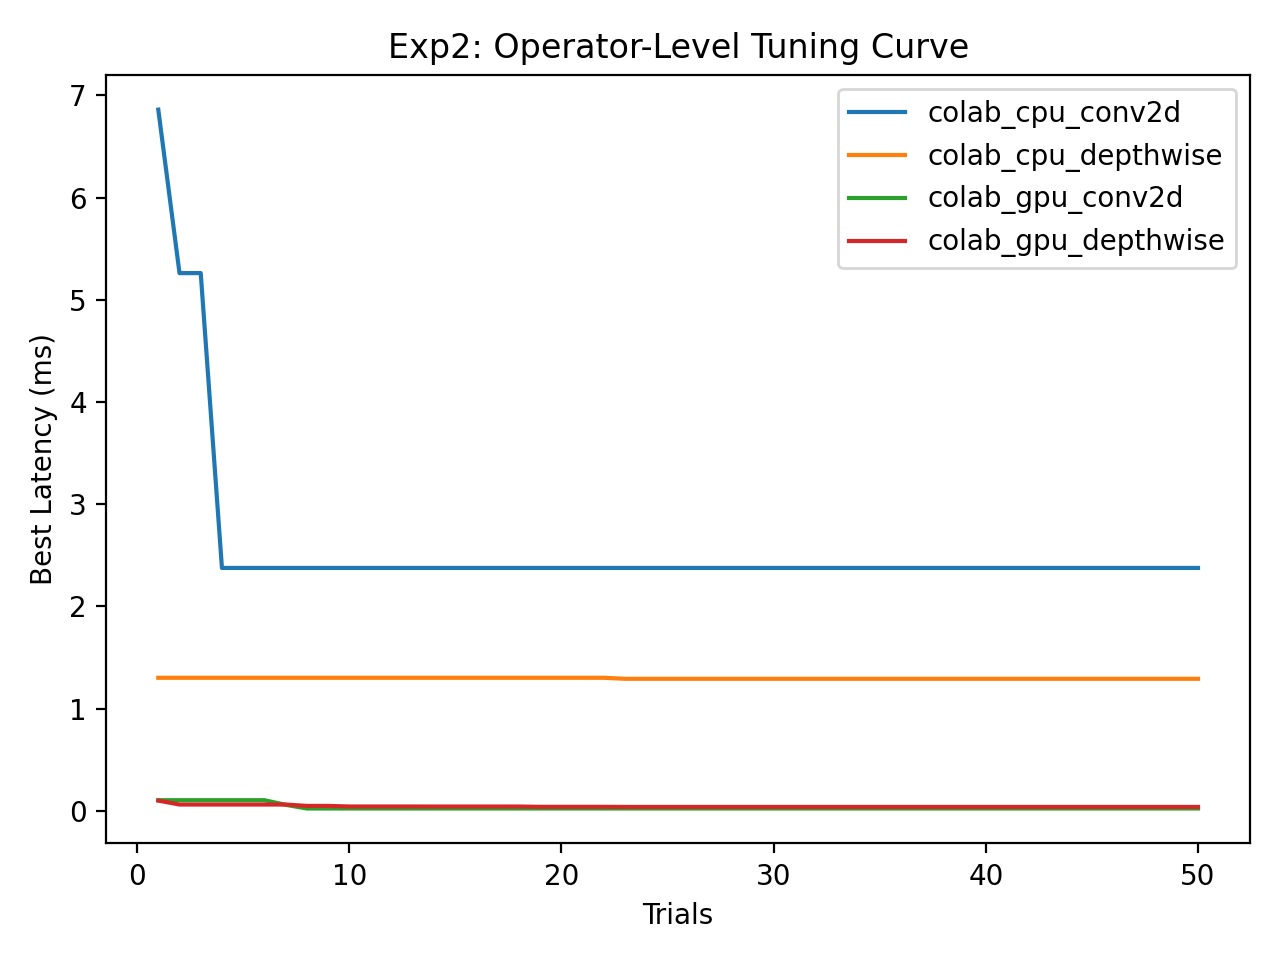

In [14]:
#@title Display
display(Image(str(EXP2_RESULTS_DIR / "tuning_curve.png")))

## Experiment 3: End-to-End

In [15]:
#@title Run on CPU
!python -m exp3_end2end.run_end2end --target llvm --platform colab_cpu --model resnet --results-dir "{EXP3_RESULTS_DIR}" --output "{EXP3_RESULTS_DIR / 'colab_cpu_resnet.json'}"
!python -m exp3_end2end.run_end2end --target llvm --platform colab_cpu --model mobilenet --results-dir "{EXP3_RESULTS_DIR}" --output "{EXP3_RESULTS_DIR / 'colab_cpu_mobilenet.json'}"

One or more operators have not been tuned. Please tune your model for better performance. Use DEBUG logging level to see more details.
{'platform': 'colab_cpu', 'model': 'resnet', 'no_opt_ms': 271.3376612990014, 'opt_ms': 260.23305578799955, 'speedup': 1.042671771567899}
Saved: /content/drive/MyDrive/tvm-osdi18-reproduction/exp3_end2end/results/colab_cpu_resnet.json
One or more operators have not been tuned. Please tune your model for better performance. Use DEBUG logging level to see more details.
{'platform': 'colab_cpu', 'model': 'mobilenet', 'no_opt_ms': 125.86504425100065, 'opt_ms': 95.92643596699781, 'speedup': 1.3120996624361485}
Saved: /content/drive/MyDrive/tvm-osdi18-reproduction/exp3_end2end/results/colab_cpu_mobilenet.json


In [16]:
#@title Run on GPU
!python -m exp3_end2end.run_end2end --target cuda --platform colab_gpu --model resnet --results-dir "{EXP3_RESULTS_DIR}" --output "{EXP3_RESULTS_DIR / 'colab_gpu_resnet.json'}"
!python -m exp3_end2end.run_end2end --target cuda --platform colab_gpu --model mobilenet --results-dir "{EXP3_RESULTS_DIR}" --output "{EXP3_RESULTS_DIR / 'colab_gpu_mobilenet.json'}"

One or more operators have not been tuned. Please tune your model for better performance. Use DEBUG logging level to see more details.
{'platform': 'colab_gpu', 'model': 'resnet', 'no_opt_ms': 2.6912815589967067, 'opt_ms': 1.759349578002002, 'speedup': 1.5297025631785182}
Saved: /content/drive/MyDrive/tvm-osdi18-reproduction/exp3_end2end/results/colab_gpu_resnet.json
One or more operators have not been tuned. Please tune your model for better performance. Use DEBUG logging level to see more details.
{'platform': 'colab_gpu', 'model': 'mobilenet', 'no_opt_ms': 1.7888613390023238, 'opt_ms': 1.1831438959980005, 'speedup': 1.5119558534284547}
Saved: /content/drive/MyDrive/tvm-osdi18-reproduction/exp3_end2end/results/colab_gpu_mobilenet.json


In [17]:
#@title Plot
!python -m exp3_end2end.plot --results-dir "{EXP3_RESULTS_DIR}" --output "{EXP3_RESULTS_DIR / 'end2end.png'}"

Saved: /content/drive/MyDrive/tvm-osdi18-reproduction/exp3_end2end/results/end2end.png


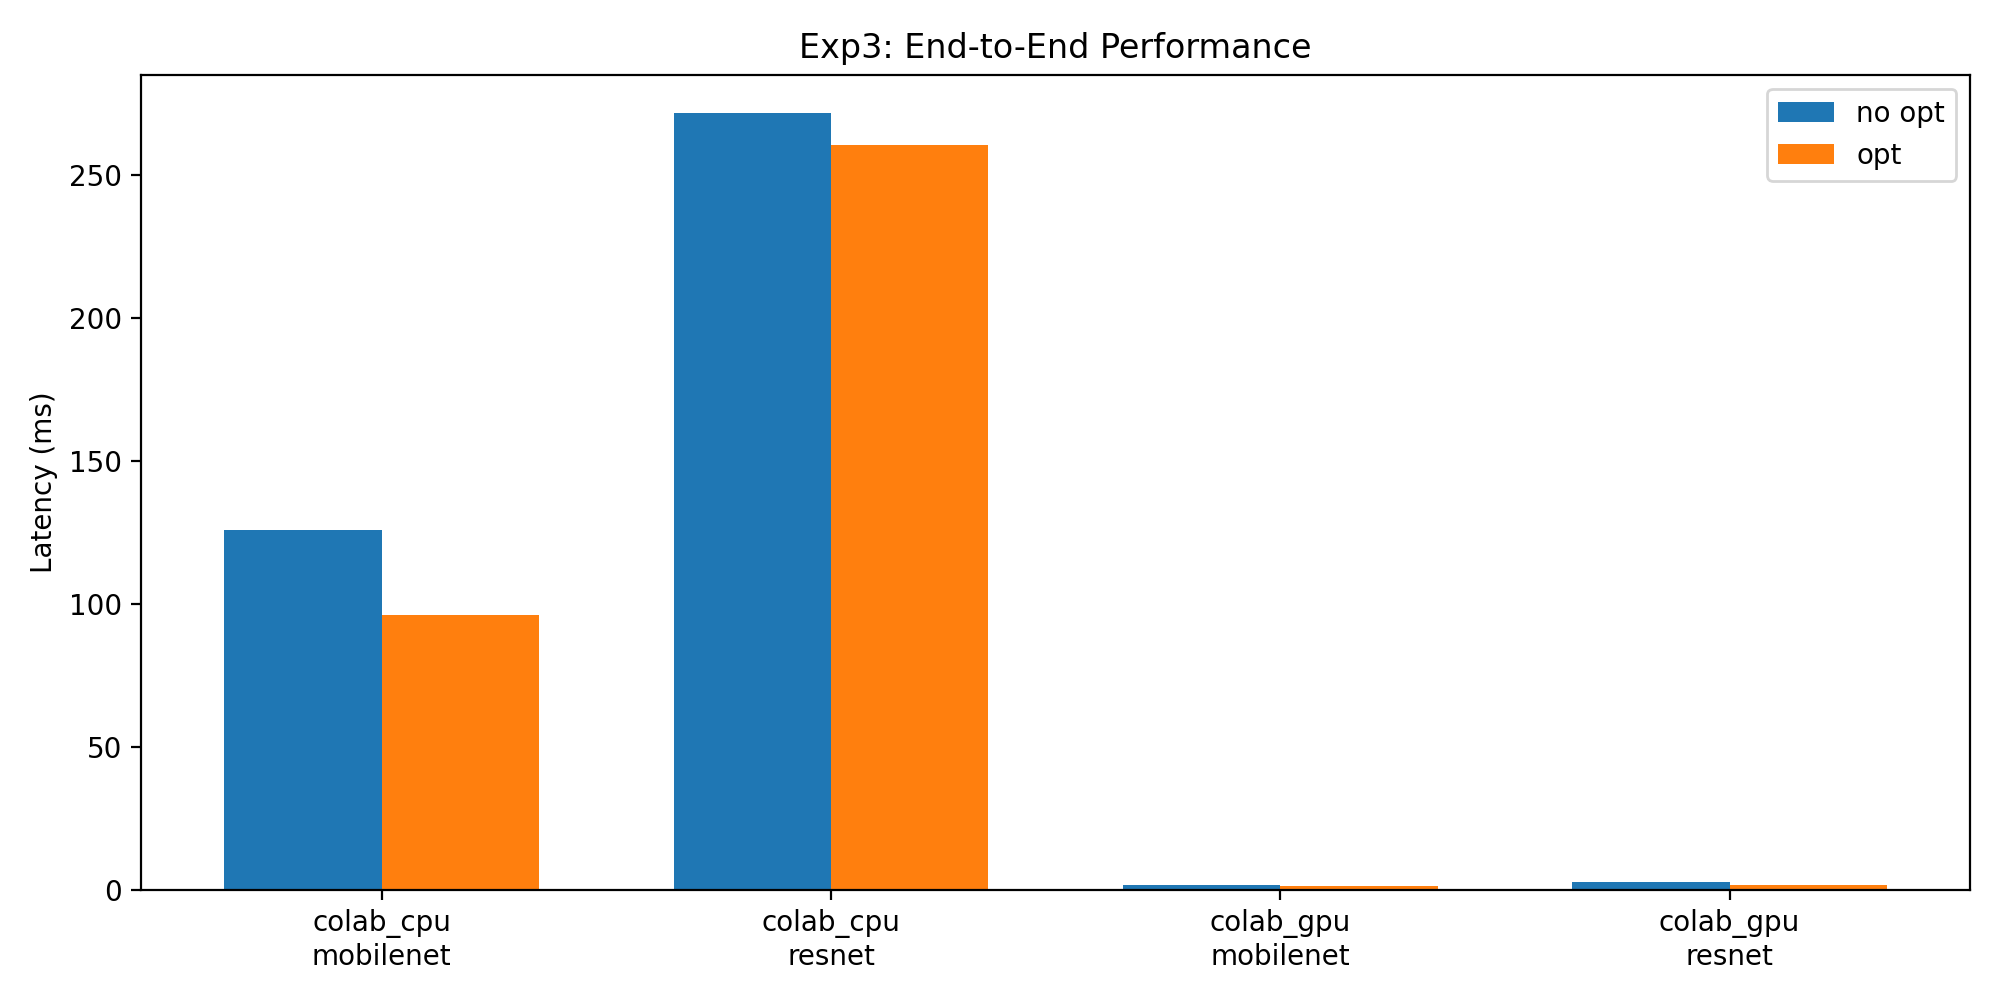

In [18]:
#@title Display
display(Image(str(EXP3_RESULTS_DIR / "end2end.png")))

## Heavy Workload Experiments on GPU

In [19]:
#@title Run Experiment 1 on GPU
!python -m exp1_graph_level.run_fusion --target cuda --platform colab_gpu_heavy --workload conv_bias_relu --batch-size 16 --height 224 --width 224 --in-channels 32 --out-channels 128 --kernel-size 3 --repeat 20 --number 200 --output "{EXP1_RESULTS_DIR / 'colab_gpu_heavy_conv_bias_relu.json'}"
!python -m exp1_graph_level.run_fusion --target cuda --platform colab_gpu_heavy --workload conv_bn_relu --batch-size 16 --height 224 --width 224 --in-channels 32 --out-channels 128 --kernel-size 3 --repeat 20 --number 200 --output "{EXP1_RESULTS_DIR / 'colab_gpu_heavy_conv_bn_relu.json'}"

Exp1: Graph-Level Optimization
Platform: colab_gpu_heavy
Target: cuda
Workload: conv_bias_relu
No graph optimization mean latency: 31.876131 ms
Graph optimization mean latency:    20.985498 ms
Speedup: 1.5190x
Saved results to: /content/drive/MyDrive/tvm-osdi18-reproduction/exp1_graph_level/results/colab_gpu_heavy_conv_bias_relu.json
Exp1: Graph-Level Optimization
Platform: colab_gpu_heavy
Target: cuda
Workload: conv_bn_relu
No graph optimization mean latency: 40.061021 ms
Graph optimization mean latency:    21.307687 ms
Speedup: 1.8801x
Saved results to: /content/drive/MyDrive/tvm-osdi18-reproduction/exp1_graph_level/results/colab_gpu_heavy_conv_bn_relu.json


One or more operators have not been tuned. Please tune your model for better performance. Use DEBUG logging level to see more details.
One or more operators have not been tuned. Please tune your model for better performance. Use DEBUG logging level to see more details.


In [20]:
#@title Plot
!python -m exp1_graph_level.plot --results-dir "{EXP1_RESULTS_DIR}" --output "{EXP1_RESULTS_DIR / 'fusion_comparison.png'}" --summary-output "{EXP1_RESULTS_DIR / 'summary.json'}"

Saved: /content/drive/MyDrive/tvm-osdi18-reproduction/exp1_graph_level/results/fusion_comparison.png


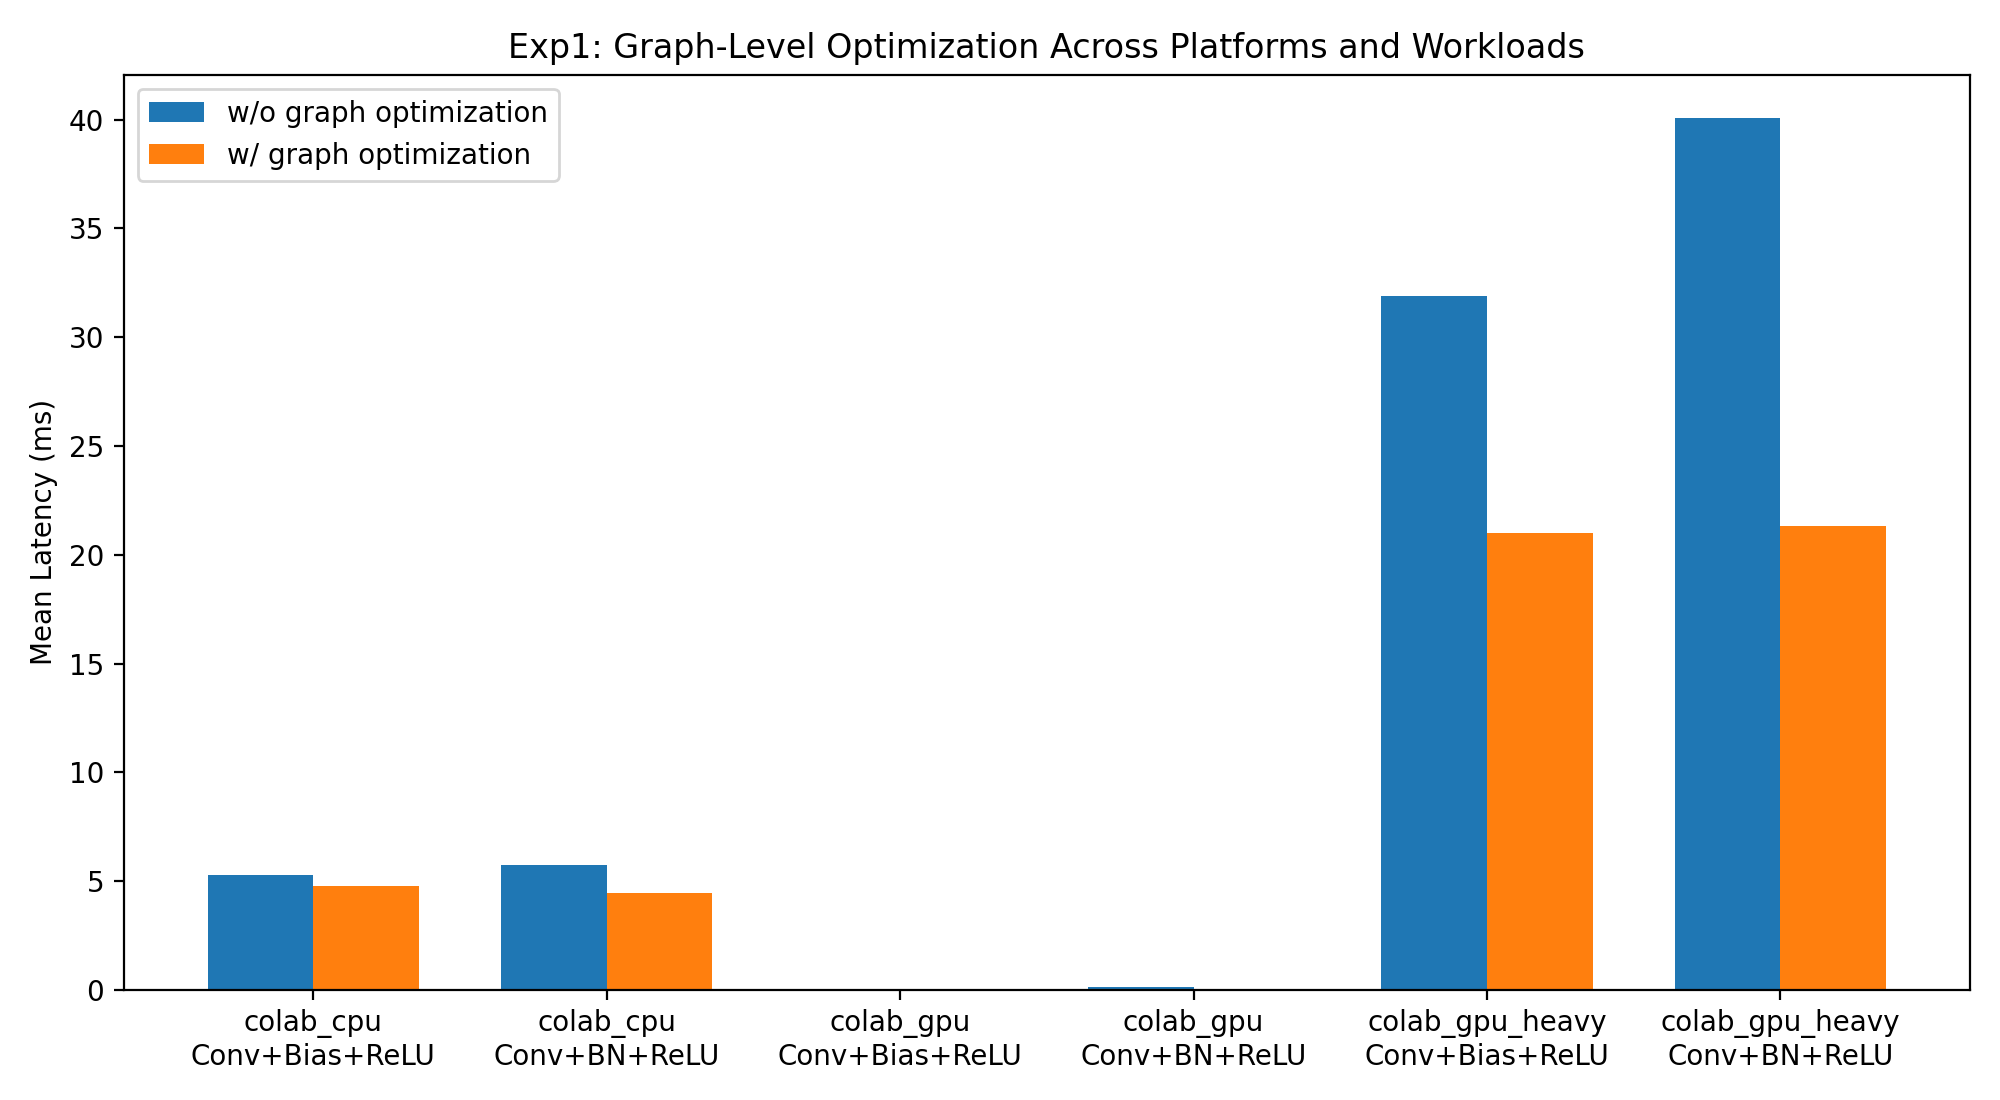

In [21]:
#@title Display
display(Image(str(EXP1_RESULTS_DIR / "fusion_comparison.png")))

In [22]:
#@title Run Experiment 2 on GPU
!python -m exp2_operator_level.run_tuning --target cuda --platform colab_gpu_heavy --workload conv2d --trials 100 --batch-size 8 --height 224 --width 224 --in-channels 32 --out-channels 128 --kernel-size 3 --results-dir "{EXP2_RESULTS_DIR}" --output "{EXP2_RESULTS_DIR / 'colab_gpu_heavy_conv2d.json'}" --log-output "{EXP2_RESULTS_DIR / 'colab_gpu_heavy_conv2d_log.json'}"
!python -m exp2_operator_level.run_tuning --target cuda --platform colab_gpu_heavy --workload depthwise --trials 100 --batch-size 8 --height 224 --width 224 --channels 64 --kernel-size 3 --results-dir "{EXP2_RESULTS_DIR}" --output "{EXP2_RESULTS_DIR / 'colab_gpu_heavy_depthwise.json'}" --log-output "{EXP2_RESULTS_DIR / 'colab_gpu_heavy_depthwise_log.json'}"

----------------------------------------------------------------------
------------------------------  [ Search ]
----------------------------------------------------------------------
Generate Sketches		#s: 1
Sample Initial Population	#s: 52	fail_ct: 6092	Time elapsed: 66.27
GA Iter: 0	Max score: 0.9735	Min score: 0.0029	#Pop: 52	#M+: 0	#M-: 0
GA Iter: 4	Max score: 1.0000	Min score: 0.9773	#Pop: 128	#M+: 1391	#M-: 0
EvolutionarySearch		#s: 128	Time elapsed: 286.77
----------------------------------------------------------------------
------------------------------  [ Measure ]
----------------------------------------------------------------------
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:numexpr.utils:NumExpr defau

In [23]:
#@title Plot
!python -m exp2_operator_level.plot --results-dir "{EXP2_RESULTS_DIR}" --output "{EXP2_RESULTS_DIR / 'tuning_curve.png'}"

Saved: /content/drive/MyDrive/tvm-osdi18-reproduction/exp2_operator_level/results/tuning_curve.png


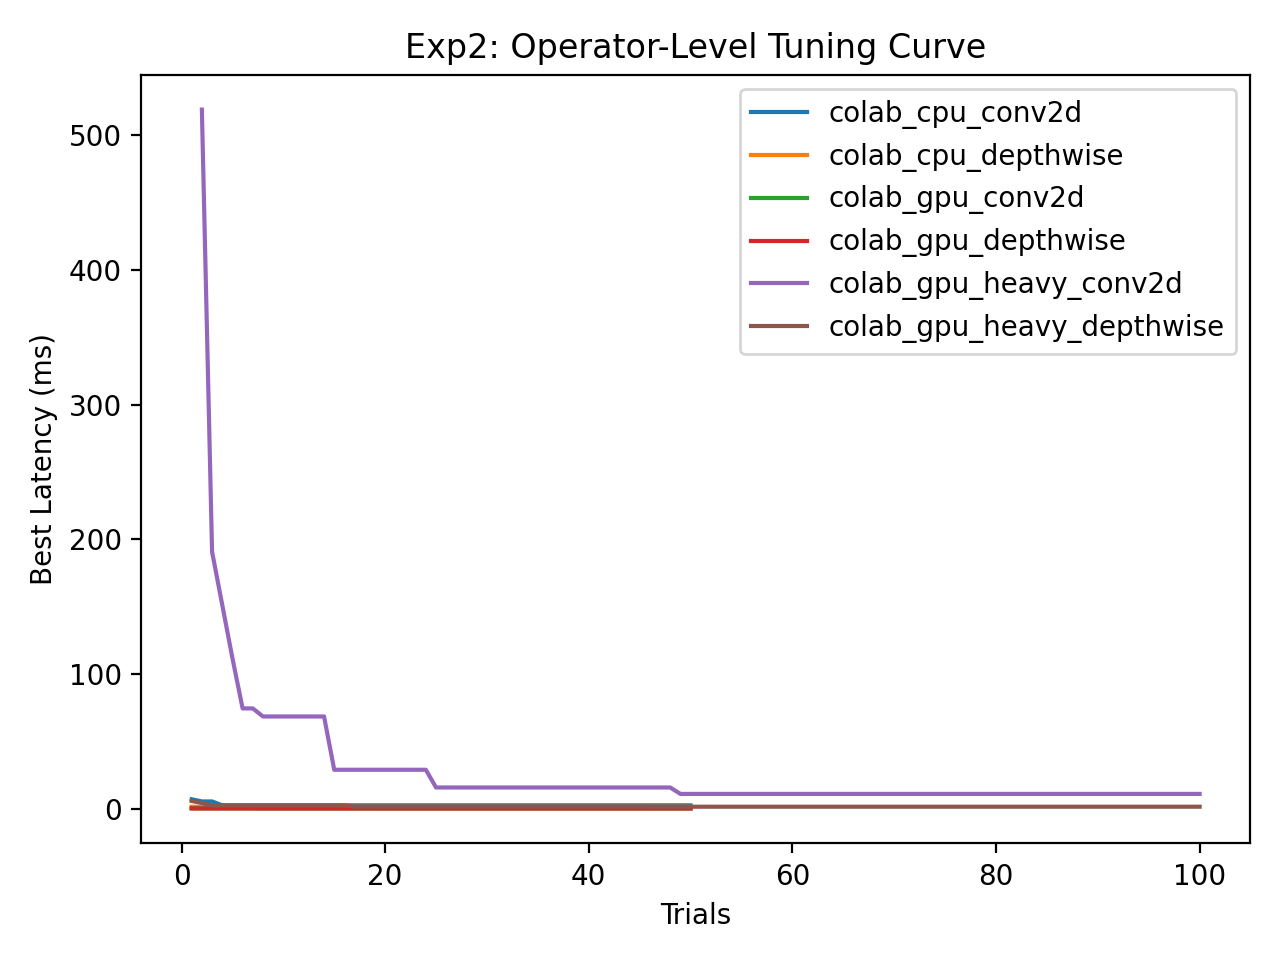

In [24]:
#@title Display
display(Image(str(EXP2_RESULTS_DIR / "tuning_curve.png")))

In [25]:
#@title Run Experiment 3 on GPU
!python -m exp3_end2end.run_end2end --target cuda --platform colab_gpu_heavy --model resnet --batch-size 8 --repeat 10 --number 100 --warmup 5 --results-dir "{EXP3_RESULTS_DIR}" --output "{EXP3_RESULTS_DIR / 'colab_gpu_heavy_resnet.json'}"
!python -m exp3_end2end.run_end2end --target cuda --platform colab_gpu_heavy --model mobilenet --batch-size 8 --repeat 10 --number 100 --warmup 5 --results-dir "{EXP3_RESULTS_DIR}" --output "{EXP3_RESULTS_DIR / 'colab_gpu_heavy_mobilenet.json'}"

One or more operators have not been tuned. Please tune your model for better performance. Use DEBUG logging level to see more details.
{'platform': 'colab_gpu_heavy', 'target': 'cuda', 'model': 'resnet', 'batch_size': 8, 'no_opt_ms': 22.131544165997184, 'opt_ms': 19.299912851000045, 'speedup': 1.1467173109463247, 'settings': {'no_opt': {'latencies_ms': [21.42943409999134, 21.474693639993347, 21.655013950003195, 21.847978810001223, 22.046728039986192, 22.214876010002627, 22.420122099993023, 22.591509120011324, 22.78086020000046, 22.854225689989107], 'mean_ms': 22.131544165997184, 'std_ms': 0.49847410842240053, 'min_ms': 21.42943409999134, 'max_ms': 22.854225689989107, 'repeat': 10, 'number': 100, 'warmup': 5}, 'opt': {'latencies_ms': [14.476360509997903, 19.306564750004327, 19.407744299987826, 19.599050849992636, 19.72119977001057, 19.94772557000033, 20.156526060000033, 20.145866990005743, 20.110734720001346, 20.12735498999973], 'mean_ms': 19.299912851000045, 'std_ms': 1.635740620538136

In [26]:
#@title Plot
!python -m exp3_end2end.plot --results-dir "{EXP3_RESULTS_DIR}" --output "{EXP3_RESULTS_DIR / 'end2end.png'}"

Saved: /content/drive/MyDrive/tvm-osdi18-reproduction/exp3_end2end/results/end2end.png


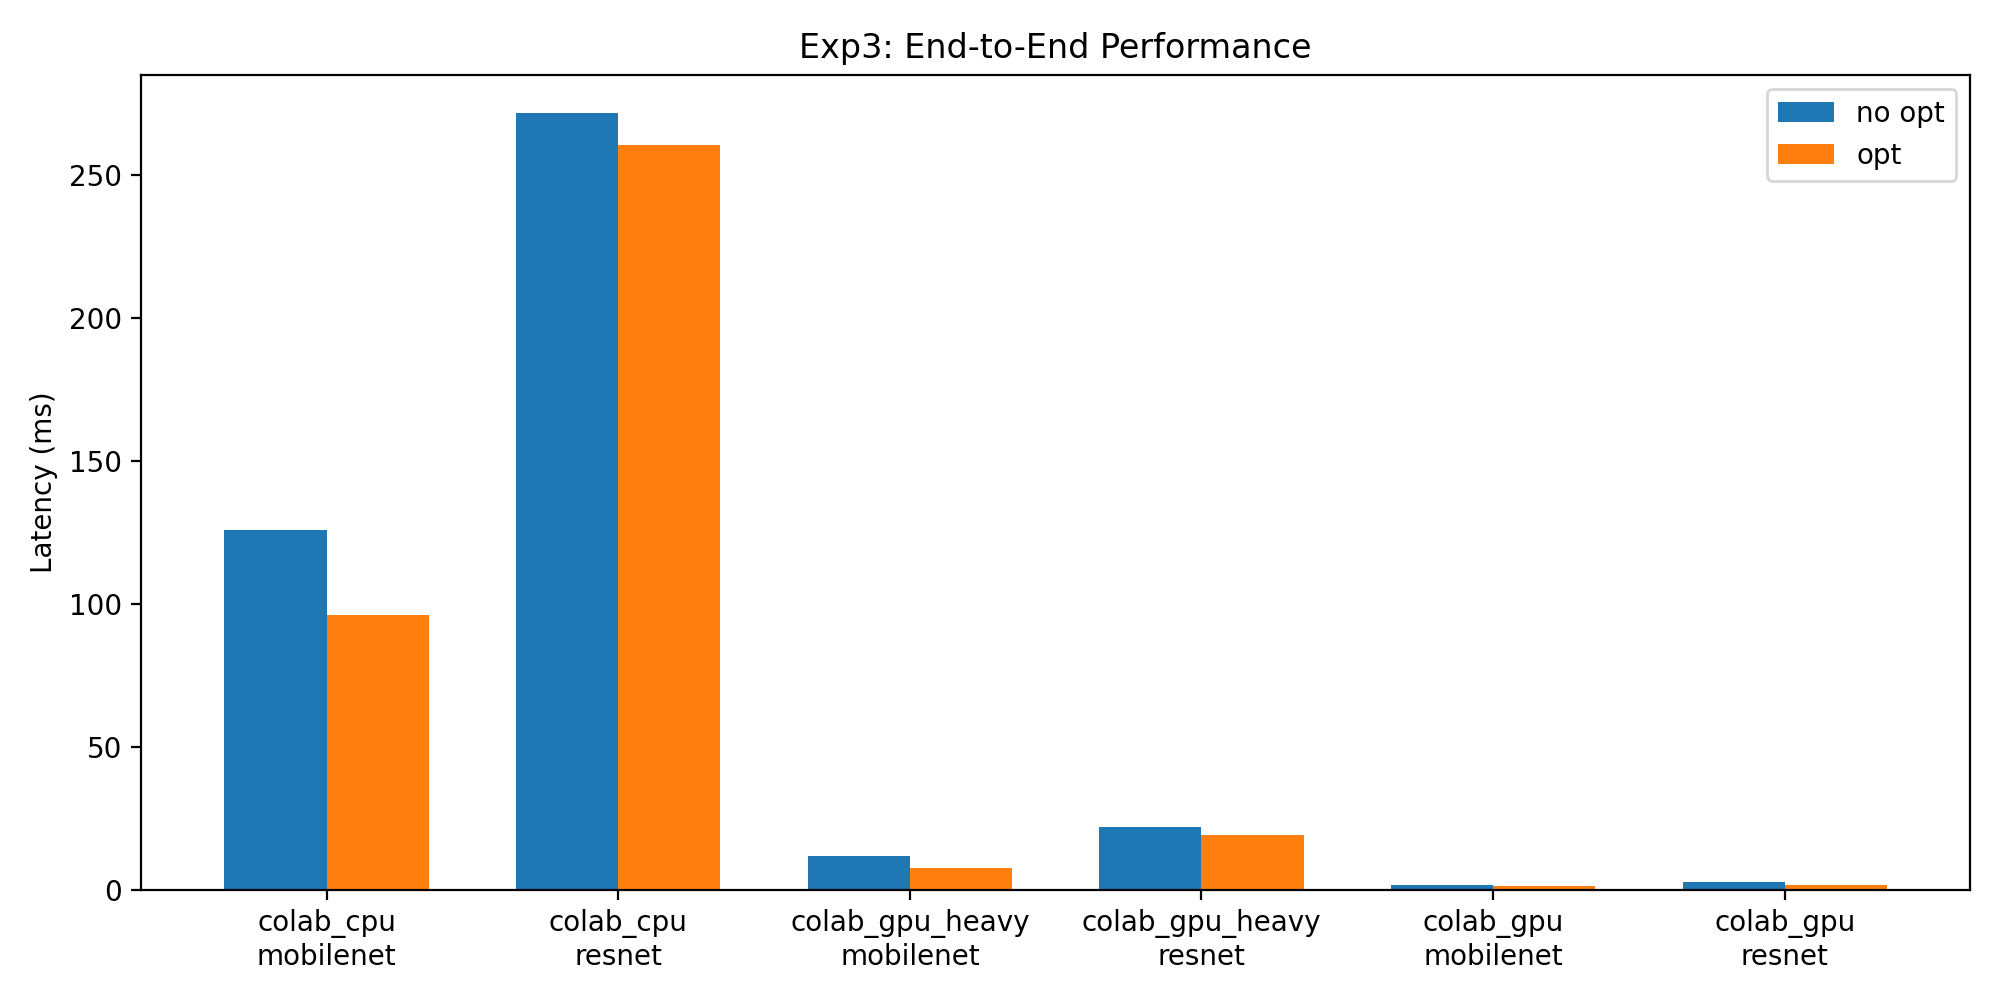

In [27]:
#@title Display
display(Image(str(EXP3_RESULTS_DIR / "end2end.png")))